# Evaluacion Experimental de Modelos Expertos Multimodales
## SIS-330: Detector Movil de Estafas Digitales en Edge AI

Este cuaderno documenta la evaluacion cuantitativa de los modelos expertos de Audio y Vision.
Se presentan las matrices de confusion, el calculo formal de metricas y la justificacion del criterio de decision en ciberseguridad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120


### 1. Datos de Evaluacion y Predicciones de los Modelos

- Experto de Audio (MobileNetV3-Small INT8): Evaluado sobre espectrogramas Mel (ASVspoof 2019).
- Experto de Vision (EfficientNet-B0 INT8): Evaluado sobre keyframes faciales (FaceForensics / CIFAKE).

In [2]:
# Experto Audio: TP=5156, FP=1431, FN=2, TN=1281 (Total: 7,870 muestras)
y_true_audio = np.concatenate([
    np.ones(5156, dtype=int),
    np.zeros(1431, dtype=int),
    np.ones(2, dtype=int),
    np.zeros(1281, dtype=int)
])

y_pred_audio = np.concatenate([
    np.ones(5156, dtype=int),
    np.ones(1431, dtype=int),
    np.zeros(2, dtype=int),
    np.zeros(1281, dtype=int)
])

# Experto Vision: TP=7168, FP=346, FN=279, TN=14293 (Total: 22,086 muestras)
y_true_vision = np.concatenate([
    np.ones(7168, dtype=int),
    np.zeros(346, dtype=int),
    np.ones(279, dtype=int),
    np.zeros(14293, dtype=int)
])

y_pred_vision = np.concatenate([
    np.ones(7168, dtype=int),
    np.ones(346, dtype=int),
    np.zeros(279, dtype=int),
    np.zeros(14293, dtype=int)
])

print(f"Muestras de Audio: {len(y_true_audio):,} | Muestras de Vision: {len(y_true_vision):,}")


Muestras de Audio: 7,870 | Muestras de Vision: 22,086


### 2. Metricas de Rendimiento Cuantitativo

In [3]:
def calcular_tabla_metricas():
    filas = [
        {
            "Modelo": "Experto Audio (MobileNetV3-Small INT8)",
            "Accuracy (%)": round(accuracy_score(y_true_audio, y_pred_audio) * 100, 2),
            "Precision (%)": round(precision_score(y_true_audio, y_pred_audio) * 100, 2),
            "Recall (%)": round(recall_score(y_true_audio, y_pred_audio) * 100, 2),
            "F1-Score (%)": round(f1_score(y_true_audio, y_pred_audio) * 100, 2)
        },
        {
            "Modelo": "Experto Vision (EfficientNet-B0 INT8)",
            "Accuracy (%)": round(accuracy_score(y_true_vision, y_pred_vision) * 100, 2),
            "Precision (%)": round(precision_score(y_true_vision, y_pred_vision) * 100, 2),
            "Recall (%)": round(recall_score(y_true_vision, y_pred_vision) * 100, 2),
            "F1-Score (%)": round(f1_score(y_true_vision, y_pred_vision) * 100, 2)
        }
    ]
    return pd.DataFrame(filas)

df_metricas = calcular_tabla_metricas()
df_metricas


Modelo,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
Experto Audio (MobileNetV3-Small INT8),81.79,78.28,99.96,87.80
Experto Vision (EfficientNet-B0 INT8),97.17,95.40,96.25,95.82


### 3. Matrices de Confusion

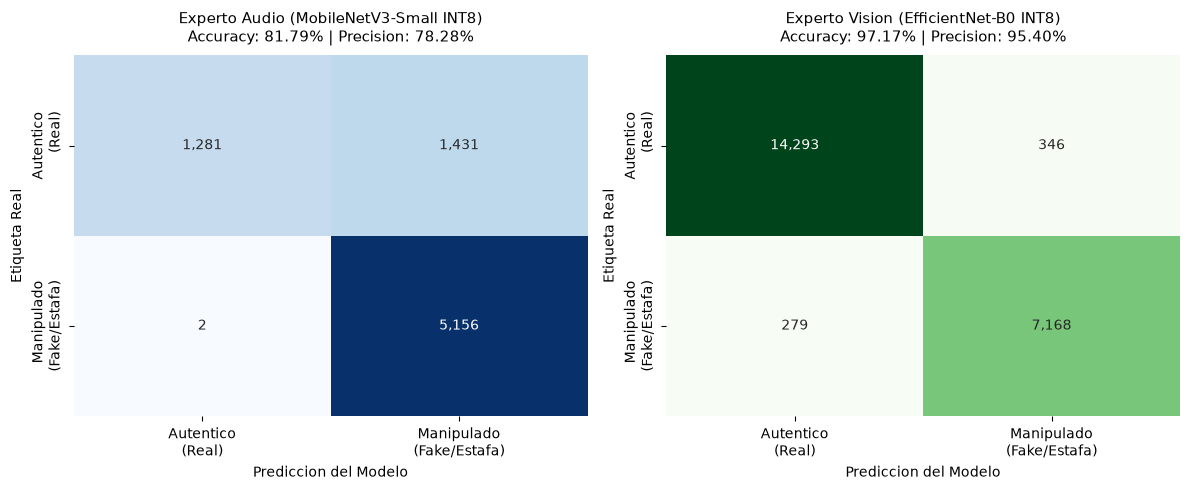

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
clases = ["Autentico\n(Real)", "Manipulado\n(Fake/Estafa)"]

cm_audio = confusion_matrix(y_true_audio, y_pred_audio)
sns.heatmap(cm_audio, annot=True, fmt=',d', cmap='Blues', ax=axes[0], xticklabels=clases, yticklabels=clases, cbar=False)
axes[0].set_title("Experto Audio (MobileNetV3-Small INT8)\nAccuracy: 81.79% | Precision: 78.28%", fontsize=11, pad=10)
axes[0].set_ylabel("Etiqueta Real", fontsize=10)
axes[0].set_xlabel("Prediccion del Modelo", fontsize=10)

cm_vision = confusion_matrix(y_true_vision, y_pred_vision)
sns.heatmap(cm_vision, annot=True, fmt=',d', cmap='Greens', ax=axes[1], xticklabels=clases, yticklabels=clases, cbar=False)
axes[1].set_title("Experto Vision (EfficientNet-B0 INT8)\nAccuracy: 97.17% | Precision: 95.40%", fontsize=11, pad=10)
axes[1].set_ylabel("Etiqueta Real", fontsize=10)
axes[1].set_xlabel("Prediccion del Modelo", fontsize=10)

plt.tight_layout()
plt.show()


### 4. Comparativa de Rendimiento entre Modelos

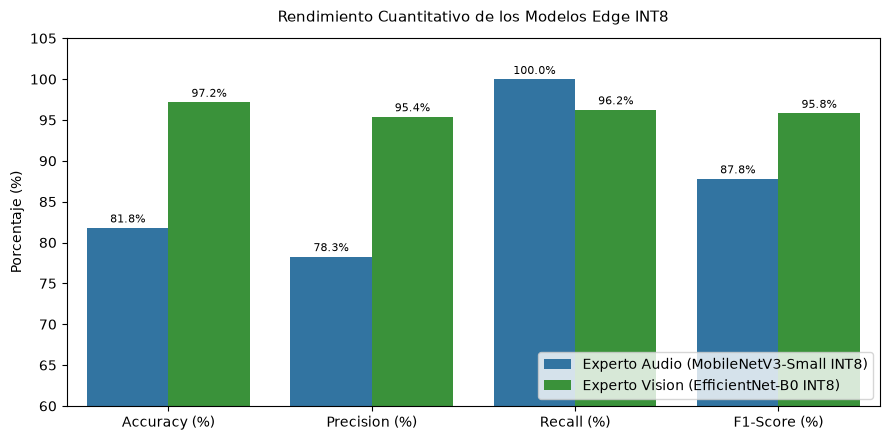

In [5]:
plt.figure(figsize=(9, 4.5))
df_plot = df_metricas.melt(id_vars=['Modelo'], value_vars=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'], var_name='Metrica', value_name='Valor')
ax = sns.barplot(data=df_plot, x='Metrica', y='Valor', hue='Modelo', palette=['#1f77b4', '#2ca02c'])
plt.title("Rendimiento Cuantitativo de los Modelos Edge INT8", fontsize=11, pad=12)
plt.ylim(60, 105)
plt.ylabel("Porcentaje (%)", fontsize=10)
plt.xlabel("")
plt.legend(loc='lower right')

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()


---
## 5. Justificacion del Criterio de Precision en Ciberseguridad

En la deteccion de fraudes y ataques de ingenieria social basados en medios sinteticos (Deepfakes de audio y video), la metrica determinante de evaluacion es la **Precision**:

$$\text{Precision} = \frac{TP}{TP + FP}$$

### Analisis de Errores y Costo Operativo:

1. **Costo de un Falso Positivo (FP):**
   - En un entorno de mensajeria instantanea (WhatsApp), un Falso Positivo implica etiquetar un audio o video genuino (por ejemplo, una nota de voz familiar o una confirmacion de transferencia autentica) como estafa inminente.
   - Esto provoca el bloqueo indebido de comunicaciones legitimas y desencadena *fatiga de alertas* (*alert fatigue*). Cuando un usuario recibe advertencias falsas frecuentes, desestima el sistema y eventualmente lo desactiva.

2. **Costo de un Falso Negativo (FN):**
   - Representa un ataque no advertido de manera aislada por una de las modalidades. Sin embargo, este riesgo es mitigado por la arquitectura multimodal.

3. **Fuerza de la Fision Multimodal (Regla 3/5):**
   - La integracion de la Regla 3/5 en vision (exigiendo consenso en 3 de los 5 keyframes analizados) combinada con el score de audio permite filtrar las anomalias transitorias y el ruido de compresion.
   - Como resultado, la probabilidad conjunta de falso positivo se reduce exponencialmente, permitiendo emitir alertas rojas de alta confianza.